# Notebook 3 (V4_3) — Unbalanced-Growth Branch (u-Path)

Along the all-$u$ history $z_0 = z_1 = \cdots = z_{t-1} = u$, the
equilibrium policy vector follows V4_3's reduced state-by-state
characterization (V4_3 lines 745–855):
$$
x_t^u = (\varphi_{US,t}^u,\, \varphi_{W,t},\, \omega_t,\,
         \theta_{US,t}^*,\, \omega_t^*,\, R_{f,t},\, R_{f,t}^W).
$$
The bond shares are recovered from zero-net-supply clearing
(V4_3 lines 800–802): $\theta_{W,t}^* = 0$ and
$\theta_t = -\theta_{US,t}^*\,A_t^*/A_t$.

Successors at $t+1$ (V4_3 `recursive_next_state`, line 629 and
Branch Reduction Lemma `lem_branch_reduction`, line 1344):
- continuation in $u$ with prob $\pi$ → use $x_{t+1}^u$
- switch to $b$ with prob $1-\pi$ → use BGP at the same predetermined
  state $(N_{US,t+1}^u, N_{W,t+1})$

The forward-backward iteration:
1. Forward-compute $\{N_{US,t}^u\}, \{N_{W,t}\}$ from current
   $\{\varphi_{US,t}^u, \varphi_{W,t}\}$.
2. Solve BGP at every $(N_{US,t+1}^u, N_{W,t+1})$.
3. Backward-induct $x_t^u$ for $t = T, T-1, \ldots, 1$.
4. Update $\varphi$-paths; iterate to convergence.

The V4_3 prediction (Lemma `lem_prod_orders`, eq. `phi_u_upper_order`) is the
one-sided **upper** bound
**$\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$**,
so the per-variety dividend yield $d^u/q^u$ collapses and
$q_{US}^u/d_{US}^u$ rises (the bubble mechanism of Theorem 1). The draft proves
only $\lesssim$ (not $\asymp$), since $\varphi_{US,t}^u$ is an equilibrium object;
the empirical decay exponent approaches $\psi_{US}/\rho_{US}$ from below
(quantified in `07_v9_assumption_checks.ipynb`).

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")
using Plots, LaTeXStrings, Printf
gr()


  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


Plots.GRBackend()

In [2]:
p = ProductionParams(T_max=100)   # HKT-matched defaults; solvable to T≈100+
validate_params(p)
result = run_production_simulation(p; verbose=true)

@printf("u-branch converged: %s   max ‖F_u‖ = %.2e\n",
        result.branch_converged, result.max_u_residual)
@printf("V4_3 equity-weight min slack: %.4e   ok=%s\n",
        result.diagnostics.equity_weight_min, result.diagnostics.equity_weights_ok)
if !result.branch_converged || !(result.max_u_residual < 1e-5)
    @warn "u-branch did not meet the residual tolerance; downstream diagnostics/exports are provisional." max_u_residual=result.max_u_residual
end


Calibrating ν_b for common world growth (V4_3 G_b = G_W)...
  iter  1: ν_b -> 0.094292 (Δ=5.71e-03), ‖F‖=2.15e-12
  iter  2: ν_b -> 0.090367 (Δ=3.93e-03), ‖F‖=4.78e-13
  iter  3: ν_b -> 0.087667 (Δ=2.70e-03), ‖F‖=1.06e-13
  iter  4: ν_b -> 0.085810 (Δ=1.86e-03), ‖F‖=2.36e-14
  iter  5: ν_b -> 0.084532 (Δ=1.28e-03), ‖F‖=5.38e-15
  iter  6: ν_b -> 0.083654 (Δ=8.78e-04), ‖F‖=9.36e-16
  iter  7: ν_b -> 0.083050 (Δ=6.04e-04), ‖F‖=2.22e-16
  iter  8: ν_b -> 0.082634 (Δ=4.16e-04), ‖F‖=4.44e-16
  iter  9: ν_b -> 0.082348 (Δ=2.86e-04), ‖F‖=2.78e-16
  iter 10: ν_b -> 0.082152 (Δ=1.97e-04), ‖F‖=1.35e-16
  iter 11: ν_b -> 0.082017 (Δ=1.35e-04), ‖F‖=4.86e-10
  iter 12: ν_b -> 0.081924 (Δ=9.30e-05), ‖F‖=2.30e-10
  iter 13: ν_b -> 0.081860 (Δ=6.40e-05), ‖F‖=1.09e-10
  iter 14: ν_b -> 0.081816 (Δ=4.40e-05), ‖F‖=5.15e-11
  iter 15: ν_b -> 0.081785 (Δ=3.03e-05), ‖F‖=2.43e-11
  iter 16: ν_b -> 0.081765 (Δ=2.08e-05), ‖F‖=1.15e-11
  iter 17: ν_b -> 0.081750 (Δ=1.43e-05), ‖F‖=5.45e-12
  iter 18: ν_b -> 0.08

┌ Warning: Forward-backward did not fully converge after 30 iters.
└ @ Main ~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/TwoCountryProductionOLG.jl:1216


Computing bubble diagnostics...
  u-branch converged: true   max ‖F_u‖ = 3.94e-08

══════ V4_3 PRODUCTION-ECONOMY DIAGNOSTICS ══════
  Condition (1a) converges: false   (Σ d^u/q^u  = 5.668957)
  Condition (1b) converges: false   (Σ branch   = 98.573954)
  Geometric-tail (1a): ratio=0.9580  converges=true  Σ_∞=5.832870
  Geometric-tail (1b): ratio=0.9894  converges=true  Σ_∞=161.600374
  BUBBLE EXISTS: true  (tail, regularity, and residual checks)
  Total leakage Σ a_t = 47.914937
  V4_3 ass_regular_kernel  Ψ_t > 0: true  (min Ψ = 9.8357e-01)
  V4_3 ass_interior_equity_weights: true  (min slack = 2.4448e-02)
u-branch converged: true   max ‖F_u‖ = 3.94e-08
V4_3 equity-weight min slack: 2.4448e-02   ok=true


## 1. u-Path Trajectory of Labour Allocation and Per-Variety Stocks

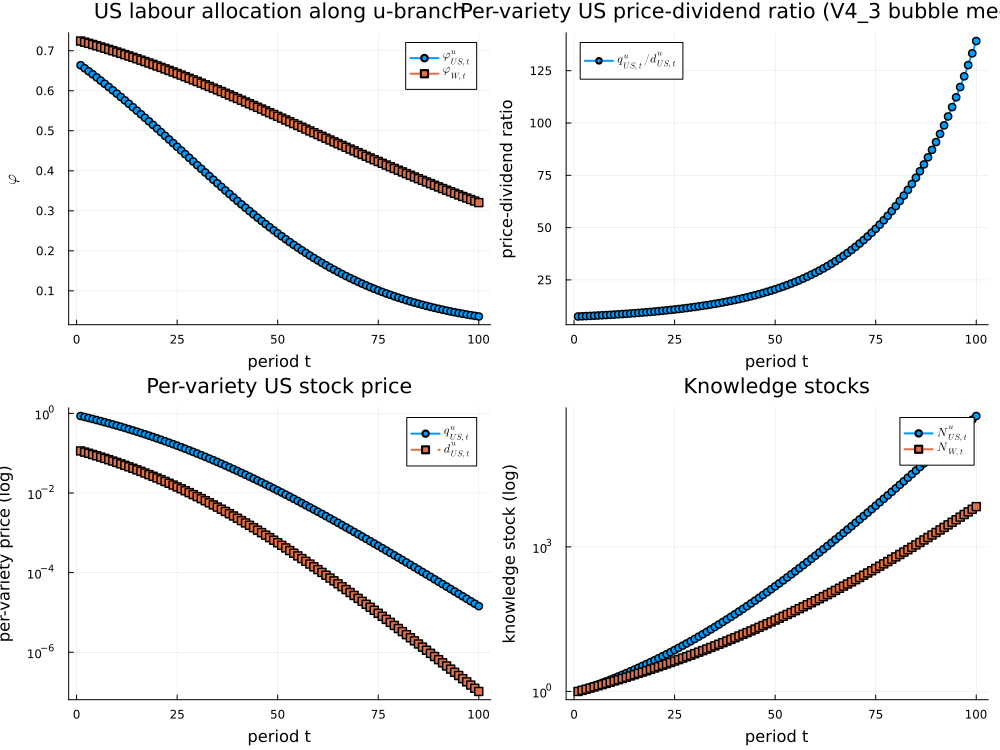

In [3]:
T = p.T_max
tt = 1:T

φ_US = [result.u_path[t].φ_US for t in tt]
φ_W  = [result.u_path[t].φ_W  for t in tt]
q_US = [result.u_path[t].q_US for t in tt]
d_US = [result.u_path[t].d_US for t in tt]
qd   = q_US ./ d_US
N_US = [result.u_path[t].N_US for t in tt]
N_W  = [result.u_path[t].N_W  for t in tt]

p1 = plot(tt, φ_US, lw=2, marker=:circle, label=L"\varphi_{US,t}^u",
          xlabel="period t", ylabel=L"\varphi",
          title="US labour allocation along u-branch")
plot!(p1, tt, φ_W, lw=2, marker=:square, label=L"\varphi_{W,t}")

p2 = plot(tt, qd, lw=2, marker=:circle, label=L"q_{US,t}^u/d_{US,t}^u",
          xlabel="period t", ylabel="price-dividend ratio",
          title="Per-variety US price-dividend ratio (V4_3 bubble mechanism)")

p3 = plot(tt, q_US, lw=2, marker=:circle, label=L"q_{US,t}^u",
          xlabel="period t", ylabel="per-variety price (log)", yscale=:log10,
          title="Per-variety US stock price")
plot!(p3, tt, d_US, lw=2, marker=:square, label=L"d_{US,t}^u", ls=:dash)

p4 = plot(tt, N_US, lw=2, marker=:circle, label=L"N_{US,t}^u",
          xlabel="period t", ylabel="knowledge stock (log)", yscale=:log10,
          title="Knowledge stocks")
plot!(p4, tt, N_W, lw=2, marker=:square, label=L"N_{W,t}")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))


## 2. Aggregate Quantities, Output Decomposition, and IPO Transfer

V4_3 eq. `country_output_income_identity` (line 217–222) gives the
**corrected** output decomposition:
$$
Y_{i,t} = e_{i,t} + \mathcal D_{i,t} - \mathcal I_{i,t},
$$
where $\mathcal I_{i,t} = (1-\varphi_{i,t}) H_i w_{H,i,t}$ is the IPO
transfer to R&D workers (V4_3 eq. `country_ipo_transfer`, line 211–214).
The V9 form $Y_i = e_i + \mathcal D_i$ omitted $\mathcal I_i$ — the
next code cell quantifies the difference along the u-path.

Aggregate market capitalisation: $\mathcal Q_{i,t} = N_{i,t+1} q_{i,t}$
(V4_3 eq. `country_stock_aggregation`).


┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105


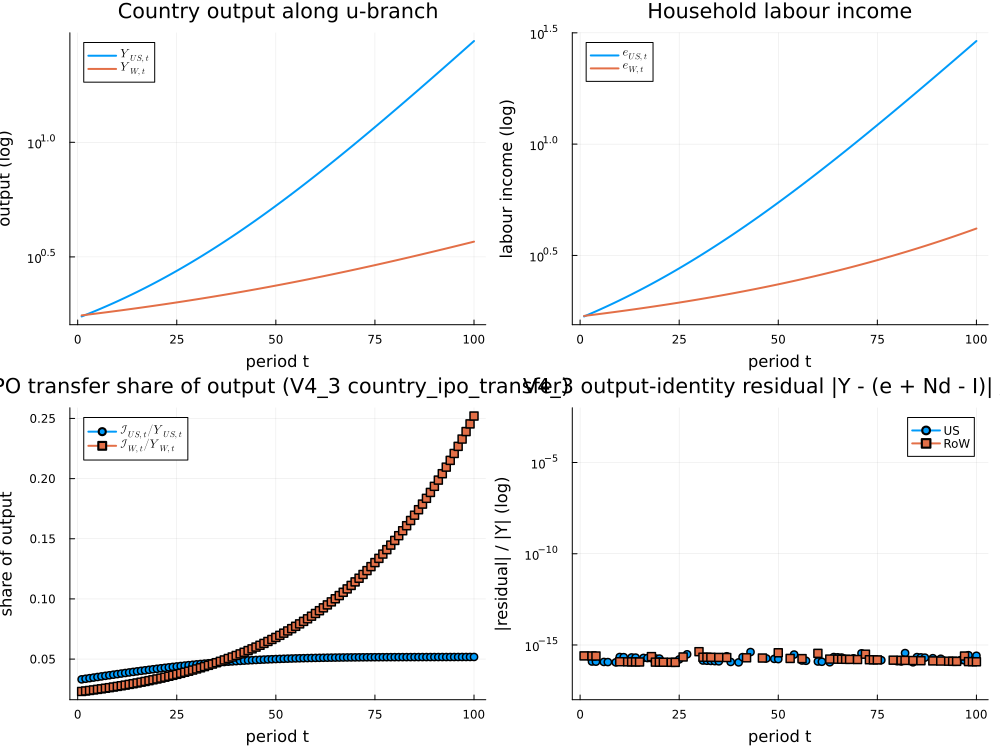

┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105


In [4]:
Y_US = [result.u_path[t].Y_US for t in tt]
Y_W  = [result.u_path[t].Y_W  for t in tt]
e_US = [result.u_path[t].e_US for t in tt]
e_W  = [result.u_path[t].e_W  for t in tt]
Q_US = [result.u_path[t].Q_US for t in tt]
Q_W  = [result.u_path[t].Q_W  for t in tt]
I_US = [result.u_path[t].I_US for t in tt]
I_W  = [result.u_path[t].I_W  for t in tt]
D_US = N_US .* d_US
rel_size = Y_W ./ Y_US

# V4_3 identity residual: Y_i - (e_i + N_i·d_i - I_i)
yid_res_US = [result.u_path[t].Y_US -
              (result.u_path[t].e_US + result.u_path[t].N_US*result.u_path[t].d_US -
               result.u_path[t].I_US) for t in tt]
yid_res_W = [result.u_path[t].Y_W -
             (result.u_path[t].e_W + result.u_path[t].N_W*result.u_path[t].d_W -
              result.u_path[t].I_W) for t in tt]

p1 = plot(tt, Y_US, lw=2, label=L"Y_{US,t}", yscale=:log10,
          xlabel="period t", ylabel="output (log)",
          title="Country output along u-branch")
plot!(p1, tt, Y_W, lw=2, label=L"Y_{W,t}")

p2 = plot(tt, e_US, lw=2, label=L"e_{US,t}", yscale=:log10,
          xlabel="period t", ylabel="labour income (log)",
          title="Household labour income")
plot!(p2, tt, e_W, lw=2, label=L"e_{W,t}")

# V4_3 IPO transfer panel
p3 = plot(tt, I_US ./ Y_US, lw=2, marker=:circle, label=L"\mathcal{I}_{US,t}/Y_{US,t}",
          xlabel="period t", ylabel="share of output",
          title="IPO transfer share of output (V4_3 country_ipo_transfer)")
plot!(p3, tt, I_W ./ Y_W, lw=2, marker=:square, label=L"\mathcal{I}_{W,t}/Y_{W,t}")

p4 = plot(tt, abs.(yid_res_US) ./ abs.(Y_US), lw=2, marker=:circle,
          label="US", yscale=:log10, ylims=(1e-18, 1e-2),
          xlabel="period t", ylabel="|residual| / |Y| (log)",
          title="V4_3 output-identity residual |Y - (e + Nd - I)| / |Y|")
plot!(p4, tt, abs.(yid_res_W) ./ abs.(Y_W), lw=2, marker=:square, label="RoW")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))


## 3. Portfolio Policies and Risk-Free Rates

The V4_3 primary bond unknown is $\theta_{US,t}^*$ (RoW US-bond demand,
positive); $\theta_t$ (US household issuance, negative) is recovered.
Both are reported below.


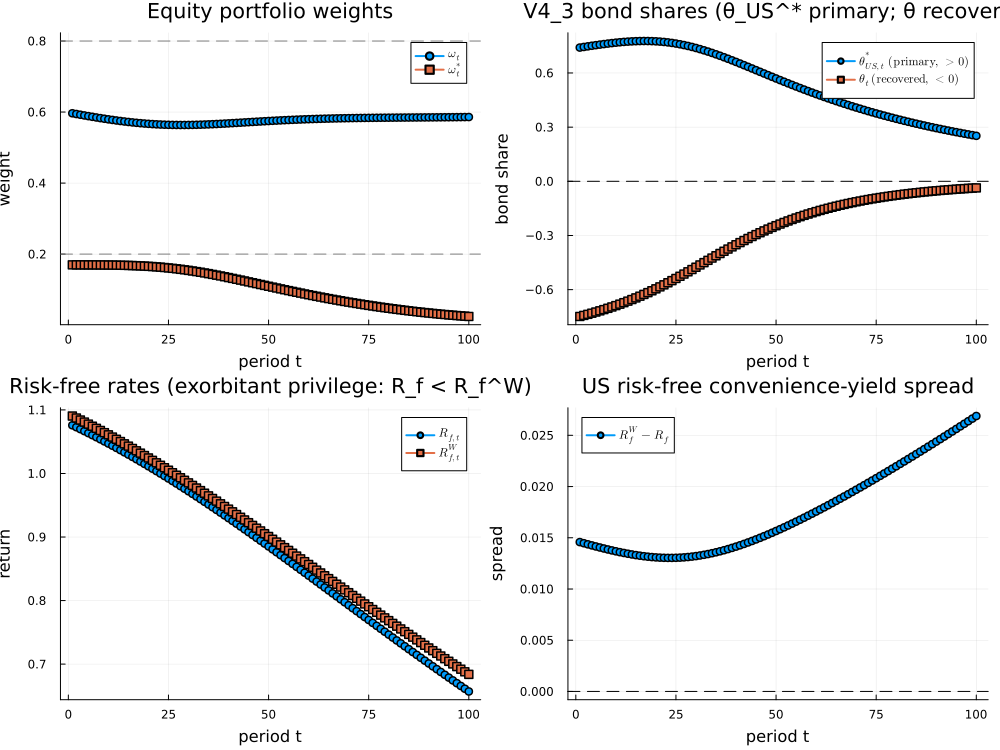

In [5]:
ω    = [result.u_path[t].ω         for t in tt]
ωs   = [result.u_path[t].ω_star    for t in tt]
θ    = [result.u_path[t].θ         for t in tt]
θUs  = [result.u_path[t].θ_US_star for t in tt]
R_f  = [result.u_path[t].R_f       for t in tt]
R_fW = [result.u_path[t].R_f_W     for t in tt]

p1 = plot(tt, ω, lw=2, marker=:circle, label=L"\omega_t",
          xlabel="period t", ylabel="weight",
          title="Equity portfolio weights")
plot!(p1, tt, ωs, lw=2, marker=:square, label=L"\omega_t^*")
hline!(p1, [p.ω̄, p.ω̄_star], ls=:dash, color=:gray, label="")

p2 = plot(tt, θUs, lw=2, marker=:circle,
          label=L"\theta_{US,t}^*\;(\mathrm{primary},\,> 0)",
          xlabel="period t", ylabel="bond share",
          title="V4_3 bond shares (θ_US^* primary; θ recovered)")
plot!(p2, tt, θ, lw=2, marker=:square,
      label=L"\theta_t\;(\mathrm{recovered},\,< 0)")
hline!(p2, [0.0], ls=:dash, color=:black, label="")

p3 = plot(tt, R_f, lw=2, marker=:circle, label=L"R_{f,t}",
          xlabel="period t", ylabel="return",
          title="Risk-free rates (exorbitant privilege: R_f < R_f^W)")
plot!(p3, tt, R_fW, lw=2, marker=:square, label=L"R_{f,t}^W")

p4 = plot(tt, R_fW .- R_f, lw=2, marker=:circle, label=L"R_f^W - R_f",
          xlabel="period t", ylabel="spread",
          title="US risk-free convenience-yield spread")
hline!(p4, [0.0], ls=:dash, color=:black, label="")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))


## 4. Market-Clearing Verification

We check the V4_3 value-form clearing equations:
$$
\mathcal Q_{US,t} = \omega_t S_t + \omega_t^* S_t^*,
\qquad
\mathcal Q_{W,t} = (1-\omega_t) S_t + (1-\omega_t^*) S_t^*,
$$
(V4_3 eqs. `intratemporal_QUS`, `intratemporal_QW`), and the V4_3 bond
clearing (line 727–729):
$$
\theta_t A_t + \theta_{US,t}^* A_t^* = 0,
\qquad
\theta_{W,t}^* A_t^* = 0.
$$
We also report the V4_3 output identity residual
$|Y_i - (e_i + \mathcal D_i - \mathcal I_i)|$ and the regularity
diagnostic $\Psi_t > 0$ (V4_3 `ass_regular_kernel`, line 1145).


Max residuals along u-path:
  US stock-market clearing       : 2.86e-07
  RoW stock-market clearing      : 5.85e-07
  Bond clearing                  : 1.11e-16
  Aggregate market-cap identity  : 8.71e-07
  V4_3 Y=e+D-I (US)              : 7.11e-15
  V4_3 Y=e+D-I (RoW)             : 8.88e-16
  V4_3 ass_regular_kernel  min Ψ : 9.8357e-01   (all positive: true)


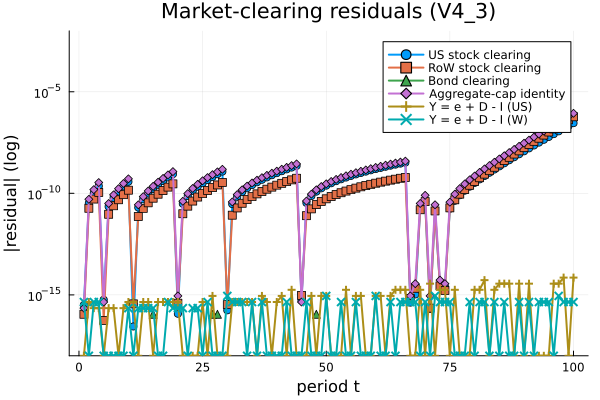

In [6]:
stock_err_US = zeros(T); stock_err_W = zeros(T); bond_err = zeros(T)
identity_err = zeros(T); yident_err_US = zeros(T); yident_err_W = zeros(T)
psi_path = zeros(T)
for t in 1:T
    s = result.u_path[t]
    stock_err_US[t] = abs(s.Q_US - s.ω*s.S - s.ω_star*s.S_star)
    stock_err_W[t]  = abs(s.Q_W - (1-s.ω)*s.S - (1-s.ω_star)*s.S_star)
    bond_err[t]     = abs(s.θ*s.A + s.θ_US_star*s.A_star)
    identity_err[t] = abs(s.Q_US + s.Q_W - (result.params.β*s.e_US + (result.params.β+result.params.χ)/(1+result.params.χ)*s.e_W))
    yident_err_US[t]= abs(s.Y_US - (s.e_US + s.N_US*s.d_US - s.I_US))
    yident_err_W[t] = abs(s.Y_W  - (s.e_W  + s.N_W *s.d_W  - s.I_W))
    psi_path[t]     = s.Psi
end

p1 = plot(tt, stock_err_US, lw=2, marker=:circle, label="US stock clearing",
          yscale=:log10, ylims=(1e-18, 1e-2),
          xlabel="period t", ylabel="|residual| (log)",
          title="Market-clearing residuals (V4_3)")
plot!(p1, tt, stock_err_W,  lw=2, marker=:square,   label="RoW stock clearing")
plot!(p1, tt, bond_err,     lw=2, marker=:utriangle, label="Bond clearing")
plot!(p1, tt, identity_err, lw=2, marker=:diamond,   label="Aggregate-cap identity")
plot!(p1, tt, max.(yident_err_US, 1e-18), lw=2, marker=:cross, label="Y = e + D - I (US)")
plot!(p1, tt, max.(yident_err_W , 1e-18), lw=2, marker=:xcross, label="Y = e + D - I (W)")

@printf("Max residuals along u-path:\n")
@printf("  US stock-market clearing       : %.2e\n", maximum(stock_err_US))
@printf("  RoW stock-market clearing      : %.2e\n", maximum(stock_err_W))
@printf("  Bond clearing                  : %.2e\n", maximum(bond_err))
@printf("  Aggregate market-cap identity  : %.2e\n", maximum(identity_err))
@printf("  V4_3 Y=e+D-I (US)              : %.2e\n", maximum(yident_err_US))
@printf("  V4_3 Y=e+D-I (RoW)             : %.2e\n", maximum(yident_err_W))
@printf("  V4_3 ass_regular_kernel  min Ψ : %.4e   (all positive: %s)\n",
        minimum(psi_path), all(>(0), psi_path))

# Soft assertion (warn but do not error)
if !all(>(0), psi_path)
    @warn "V4_3 ass_regular_kernel violated at some t along u-path."
end
p1


## 5. φ-Decay vs. the V4_3 Upper Bound $N_{US,t}^{-\psi_{US}/\rho_{US}}$

V4_3 Lemma `lem_prod_orders` (eq. `phi_u_upper_order`) proves the one-sided
**upper** bound
$\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$
with $\psi_{US} = (\xi_u - \nu_u)(\rho_{US} - 1)$ — only $\lesssim$, since
$\varphi_{US,t}^u$ is an equilibrium object, not a primitive. The numerical
trajectory below tracks this bound's slope only asymptotically: the empirical
decay exponent rises toward $\psi_{US}/\rho_{US}$ from below as $N_{US,t}$ grows
(quantified in `07_v9_assumption_checks.ipynb`), so the two-sided $\asymp$ holds
only in the limit, not at finite $t$.

V4_3 production-side decay exponent: -ψ_US/ρ_US = -0.2500


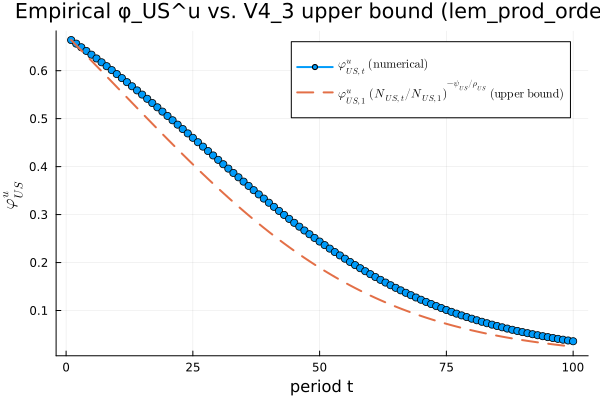

In [7]:
ψ_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
decay = ψ_US / p.ρ_US
@printf("V4_3 production-side decay exponent: -ψ_US/ρ_US = -%.4f\n", decay)

# The V4_3 curve is a one-sided UPPER bound (lem_prod_orders, eq. phi_u_upper_order),
# not a two-sided asymptote: φ_US^u stays below it, approaching its slope from below.
bound = φ_US[1] .* (N_US ./ N_US[1]).^(-decay)

plot(tt, φ_US, lw=2, marker=:circle, label=L"\varphi_{US,t}^u\,(\mathrm{numerical})",
     xlabel="period t", ylabel=L"\varphi_{US}^u",
     title="Empirical φ_US^u vs. V4_3 upper bound (lem_prod_orders)")
plot!(tt, bound, lw=2, ls=:dash,
      label=L"\varphi_{US,1}^u\,(N_{US,t}/N_{US,1})^{-\psi_{US}/\rho_{US}}\ \mathrm{(upper\ bound)}")

## Summary

- The forward-backward iteration solves the V4_3 reduced 7-equation
  Markov competitive equilibrium system (lines 745–855) along the
  u-branch in primary unknowns
  $x_t^u = (\varphi_{US,t}^u, \varphi_{W,t}, \omega_t,
   \theta_{US,t}^*, \omega_t^*, R_{f,t}, R_{f,t}^W)$.
- $\varphi_{US,t}^u$ declines monotonically, staying **below** the V4_3
  one-sided upper bound $N_{US,t}^{-\psi_{US}/\rho_{US}}$
  (Lemma `lem_prod_orders`, eq. `phi_u_upper_order`); the empirical decay
  exponent approaches $\psi_{US}/\rho_{US}$ from below.
- $q_{US}^u/d_{US}^u$ rises, capturing the bubble mechanism.
- Stock-market clearing, bond clearing, the aggregate-cap identity,
  and the V4_3 output identity $Y_i = e_i + \mathcal D_i - \mathcal I_i$
  all hold to numerical precision.
- The IPO transfer $\mathcal I_i$ tracked here is a primitive V4_3 object
  absent from V9; its share of output is small but nonzero.
- $\Psi_t > 0$ along the entire u-branch, confirming the regularity
  prerequisite for Theorem 1 (V4_3 `ass_regular_kernel`).

Next notebook: compute Theorem 1 bubble-existence diagnostics
(V4_3 `thm_bubble_characterization`, line 1382).